In [16]:
import geopandas as gpd
from src.data_loading import data_path

ModuleNotFoundError: No module named 'src'

VIIRS VNP14IMG

In [ ]:
viirs = gpd.read_file('../data/raw/fire/SUOMI_VIIRS_C2_USA_contiguous_and_Hawaii_24h/SUOMI_VIIRS_C2_USA_contiguous_and_Hawaii_24h.shp')

DataSourceError: '../data/raw/fire/SUOMI_VIIRS_C2_USA_contiguous_and_Hawaii_24h/SUOMI_VIIRS_C2_USA_contiguous_and_Hawaii_24h.prj' not recognized as being in a supported file format.; It might help to specify the correct driver explicitly by prefixing the file path with '<DRIVER>:', e.g. 'CSV:path'.

<Axes: >

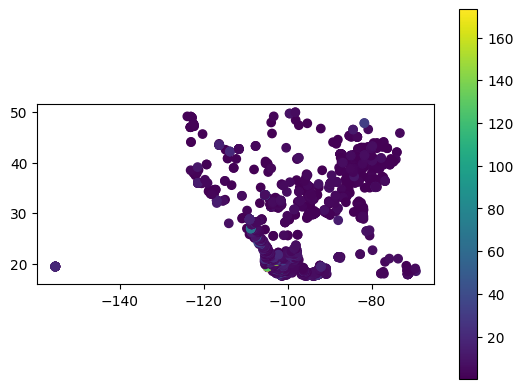

In [ ]:
viirs.plot(column='FRP', legend=True, cmap='viridis')

MCD64A1

In [29]:
import ee, geemap
ee.Initialize()

# North Carolina boundary from TIGER 2018 states
nc = (ee.FeatureCollection('TIGER/2018/States')
        .filter(ee.Filter.eq('NAME', 'North Carolina'))
        .geometry())

dataset = (ee.ImageCollection('MODIS/061/MCD64A1')
             .filter(ee.Filter.date('2017-01-01', '2018-05-01')))

# .clip per-image, then take the max BurnDate across the period
burned_area = dataset.select('BurnDate').map(lambda img: img.clip(nc))

burned_area_vis = {
    'min': 30, 'max': 341,
    'palette': ['4e0400', '951003', 'c61503', 'ff1901'],
}

m = geemap.Map()
m.center_object(nc, 7)
m.add_layer(burned_area, burned_area_vis, 'Burned Area')
m

EEException: Please authorize access to your Earth Engine account by running

earthengine authenticate

in your command line, or ee.Authenticate() in Python, and then retry.

nc boundary download

In [30]:
import geopandas as gpd

url = 'https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_500k.zip'
states = gpd.read_file(url)            # geopandas reads the zip directly
nc = states[states['NAME'] == 'North Carolina']
nc.to_file('nc_boundary.gpkg', driver='GPKG')   # GeoPackage > shapefile

earthaccess bulk download of MCD64A1

In [31]:
import earthaccess
earthaccess.login()  # uses Earthdata credentials / .netrc

results = earthaccess.search_data(
    short_name='MCD64A1',
    version='061',
    temporal=('2017-01-01', '2018-05-01'),
    bounding_box=(-84.5, 33.7, -75.4, 36.6),  # NC bbox; returns h11v05 + h12v05
)
earthaccess.download(results, './modis_raw/')

ModuleNotFoundError: No module named 'earthaccess'

# Primary Source Map — NC Peatland Fire Product Assessment

**Purpose:** authoritative starting points for working through each product row yourself.
For each product: the canonical data-host landing page (official short name, DOI, version,
coverage), the User Guide / ATBD (the definitive spec document — read this for the cells that
drive your recommendation), and the key validation/algorithm paper (cite this for performance).

**Source hierarchy (best → worst):** User Guide / ATBD  →  DAAC landing page  →  peer-reviewed
algorithm/validation paper  →  third-party explainers (orientation only, never cite).

**Workflow per product:** (1) open landing page → record short name, DOI, version, coverage,
access date; (2) download & read the User Guide / ATBD for specs + "known issues"; (3) cite the
paper for validation numbers. Keep a running notes file with DOI + version + access date for
every product (you need access dates for the federal-preservation archiving deliverable anyway).

⚠️ = spec I have NOT independently re-verified at primary source; confirm before it goes in a memo.

---

## 1. VIIRS Active Fire (VNP14IMG) — occurrence + FRP
- **Landing page:** NASA Earthdata catalog, VNP14IMG V002 — search "VNP14IMG LP DAAC"
  (lpcloud VNP14IMG-002). DOI: 10.5067/VIIRS/VNP14IMG.002
- **User Guide / ATBD:** "VIIRS 375 m Active Fire Algorithm User Guide" (LP DAAC PDF, v1.2 / June 2025).
  This has the quality flags, I4-saturation handling, and known issues.
- **Key paper:** Schroeder, Oliva, Giglio & Csiszar 2014, *Remote Sensing of Env.* 143:85–96.
- **For NC peat notes:** Sofan et al. 2020 (Indonesia peat application).
- **Note:** S-NPP end-of-life anticipated on/before Oct 2026 (NASA Earthdata) — flag for record continuity.
- **FIRMS distribution:** FIRMS VIIRS fire-hotspots description page (NRT NOAA-20 = VJ114, NOAA-21 = VJ214).

## 2. MODIS MCD64A1 (C6.1) — burned area extent
- **Landing page:** LAADS DAAC / LP DAAC MCD64A1; also MODIS_061_MCD64A1. NASA LP DAAC at USGS EROS.
- **User Guide:** "Collection 6.1 MODIS Burned Area Product User's Guide v1.0" (Giglio) — LP DAAC PDF
  (lpdaac documents/1006). Also C6 v1.3 (documents/875). Covers the hybrid VI + active-fire algorithm,
  500-m grid, burn-date-to-nearest-day encoding.
- **Key paper:** Giglio, Boschetti, Roy et al. 2018 (algorithm). Validation in peat: Vetrita et al. 2021.

## 3. FireCCI51 — burned area extent (ESA CCI)
- **Landing page:** ESA Fire CCI site + CEDA archive (search "Fire CCI FireCCI51 CEDA").
- **User Guide / ATBD:** ESA Fire_cci Product User Guide + ATBD (on the CCI/CEDA documentation page).
- **Key papers:** Lizundia-Loiola et al. 2020; Pettinari & Chuvieco (product). Peat validation: Vetrita et al. 2021.
- ⚠️ MODIS-Terra-only; 250 m. Confirm exact 2001–2020 span on CCI page.

## 4. FireCCIS311 (Sentinel-3) — burned area extent (ESA CCI)
- **Landing page:** ESA Fire CCI / CEDA (newer Sentinel-3 line).
- **User Guide / ATBD:** ESA Fire_cci S3 Product User Guide (verify it exists / version).
- ⚠️ Exact temporal span (post-2019?) MUST be verified on the CCI site — flagged in prior session as uncertain.

## 5. GABAM — 30 m annual burned area
- **Landing page / data:** Zenodo (records/17707433 = v3 2014–2024; records/13684005 = 2021). GeoTIFF tiles via GEE.
- **Key paper:** Long, Zhang et al. 2019, *Remote Sensing* 11:489 (global CE ~13%, OE ~30%).
- ⚠️ Global OE ~30% may be worse for small SE wetland fires — validate locally; no within-year timing (annual binary).

## 6. MOSEV — 500 m burn severity (dNBR/RdNBR)
- **Landing page / data:** Zenodo, DOI 10.5281/zenodo.4265209. 16-bit GeoTIFF.
- **Key paper:** Alonso-González & Fernández-García 2021, *ESSD* 13:1925.
- Built on MODIS surface reflectance + MCD64A1; inherits 500-m small-fire limitation.

## 7. MTBS — 30 m categorical severity + perimeters (US)
- **Landing page:** mtbs.gov (USGS + USFS). Shapefile + GeoTIFF.
- **Documentation:** MTBS project methods/FAQ on mtbs.gov.
- **Key paper:** Eidenshink et al. 2007.
- Size thresholds: ≥1000 ac West / ≥500 ac East — by design EXCLUDES small pocosin fires. Reference/benchmark only.

## 8. SE FireMap — 30 m continuous CBI severity, SE US (2000–2022)
- **Landing page / data:** USGS — data.usgs.gov / burnseverity.cr.usgs.gov. GeoTIFF.
- **Key paper:** Vanderhoof, Picotte, Hawbaker et al. 2025, *Int. J. Wildland Fire* (wf24137); RMSE 0.50 (SE).
- PURPOSE-BUILT for small/prescribed SE fires — strongest severity candidate here. Federal: HIGH preservation priority.

## 9. LANDFIRE — fuels / vegetation / fire-regime CONTEXT layers (not fire observations)
- **Landing page:** landfire.gov (USGS + USFS + DOI/TNC). GeoTIFF.
- **Key paper / doc:** Rollins 2009 (LANDFIRE overview) + LANDFIRE technical documentation on landfire.gov.
- Use as Phase-2 covariates (fuels, FRG, vegetation) — keep separate from fire-observation products.

---

## Cross-cutting reference (methodology, not a product)
- **Humber et al. 2019** — global burned-area product intercomparison. Methodological backbone for
  structuring your comparison / agreement analysis.
- **Vetrita et al. 2021** — MODIS-class BA validation in Indonesian peat; the "exclude <100 ha → accuracy
  jumps" finding is the core argument against relying on 500-m extent products alone for NC pocosins.

## Federal preservation flag (download + archive NC subsets early, w/ metadata + access dates)
VIIRS, MODIS/MCD64A1, MTBS, SE FireMap, LANDFIRE  (NASA / USGS / USFS).
ESA products (FireCCI51, FireCCIS311) and academic ones (GABAM-China, MOSEV-Spain) are non-federal.
